### Load Dataset

In [43]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [44]:
diabetes = load_diabetes()

In [45]:
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

In [46]:
df = pd.concat([X, y], axis=1)
print(df.to_string())

          age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646   151.0
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204    75.0
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930   141.0
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038  0.034309  0.022688 -0.009362   206.0
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142 -0.002592 -0.031988 -0.046641   135.0
5   -0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277 -0.076395 -0.041176 -0.096346    97.0
6   -0.045472  0.050680 -0.047163 -0.015999 -0.040096 -0.024800  0.000779 -0.039493 -0.062917 -0.038357   138.0
7    0.063504  0.050680 -0.001895  0.066629  0.090620  0.108914  0.022869  0.017703 -0.035816  0.003064 

Train - Test Split + Scaling

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Regularization is scale-sensitive

Scaling ensures fair penalty across features

Prevents features with large values from dominating penalty

### Train Models

L1 - Lasso (Least Absolute Shrinkage and Selection Operator)

In [49]:
models = {
    "L1 (Lasso)": Lasso(alpha=0.1),
    "L2 (Ridge)": Ridge(alpha=1.0),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [50]:
results = {}
coefficients = {}

In [51]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = (mse, r2)
    coefficients[name] = model.coef_

Here, each model applies a different penalty style.

L1 - forces some coefficients to zero

L2 - shrinks coefficients smoothly

Elastic Net - mixed behaviour

Print model performance

In [52]:
for name, (mse, r2) in results.items():
    print(f"{name}")
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("-" * 30)

L1 (Lasso)
MSE: 2884.6242887352123
R2 Score: 0.45554139902790414
------------------------------
L2 (Ridge)
MSE: 2892.0145657501726
R2 Score: 0.45414652070698225
------------------------------
Elastic Net
MSE: 2866.461255297768
R2 Score: 0.45896958196783777
------------------------------


Here, lower MSE means better performance

Higher R2 means better variance explained

So, Ridge is stable

Elastic Net balanced

Lasso slightly worse but sparse

### Plot Coefficient Comparison

In [53]:
feature_names = X.columns
x = np.arange(len(feature_names))

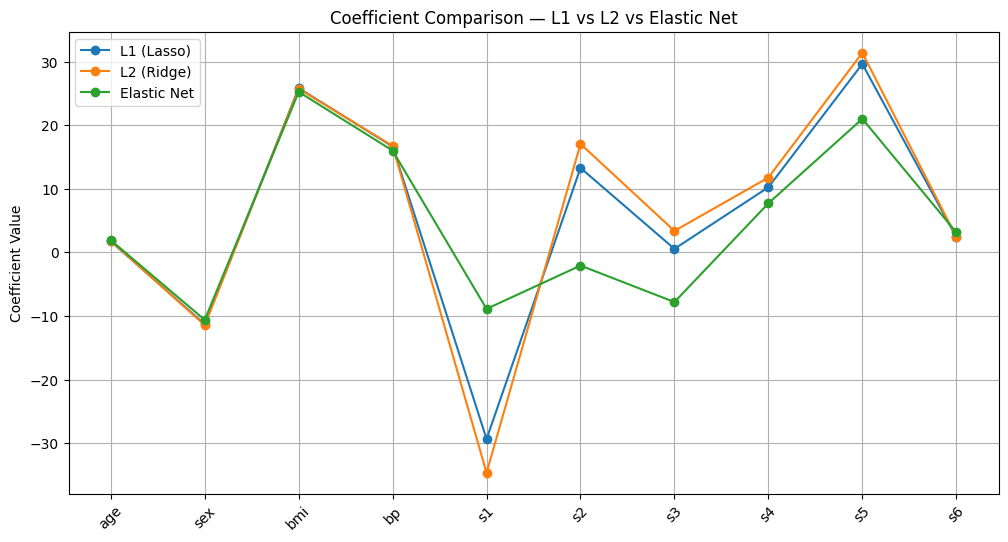

In [54]:
plt.figure(figsize=(12,6))

for name, coef in coefficients.items():
    plt.plot(x, coef, marker='o', label=name)

plt.xticks(x, feature_names, rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison — L1 vs L2 vs Elastic Net")
plt.legend()
plt.grid(True)
plt.show()

This graph shows how each regularization changes weights

L1 - Some coefficient too much nearly zero, It tries to simplify the model by removing weak features.

L2 - no zero, but smaller values, this means it reduces coefficient size but keeps every feature.

Elastic Net - some zero & some shrink, it shows like balanced shrinkage.

### Count Zero Coefficients

In [55]:
for name, coef in coefficients.items():
    zero_count = sum(coef == 0)
    print(f"{name} zero coefficients:", zero_count)

L1 (Lasso) zero coefficients: 0
L2 (Ridge) zero coefficients: 0
Elastic Net zero coefficients: 0


Overall Regularization Effects

L1 - Feature Selection

L2 - Coefficient shrinkage

Elastic Net - Balanced shrink + select

So here, L1, L2, and Elastic Net regularization were applied to the Diabetes dataset to study their effect on model training. L1 regularization produced sparse models by setting several coefficients to zero, effectively performing feature selection. L2 regularization reduced overfitting by shrinking coefficients without removing features, resulting in more stable predictions. Elastic Net combined both behaviors, providing balanced shrinkage and selective sparsity.

Overall, regularization improves generalization, reduces overfitting, and controls model complexity, with Elastic Net offering the most balanced performance among the three.